WD Categories Correlation
May 10, 2024

In [16]:
import sqlite3
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as mp
import seaborn as sb
import os

In [17]:
import psycopg2
from sqlalchemy import create_engine

In [18]:
engine = create_engine('postgresql://localhost/womens_directory_dump')

In [19]:
import pandas as pd

In [20]:
query = """
        SELECT DISTINCT ahoy_visits.id AS visit_id, category_id, cat.name
        FROM ahoy_events
        JOIN ahoy_visits ON ahoy_visits.id = ahoy_events.visit_id
        JOIN categories AS cat ON cat.id = ahoy_events.category_id
        """
cat_df = pd.read_sql_query(query, engine)
cat_df

,visit_id,category_id,name
0,1,8,Child Care and Early Childhood Devlopment
1,1,15,Baby Gear
2,5,4,Birthing Centers
3,5,9,Diagnostic Imaging/Screening
4,6,20,Rent and Utility Assistance
...,...,...,...
48806,109202,21,Food and Meal Assistance
48807,109204,1,Abortion
48808,109205,11,Mental Health and Wellness
48809,109206,27,Emergency Shelters


In [22]:
cat_df = cat_df[['visit_id', 'category_id']]
cat_df.head(10)

,visit_id,category_id
0,1,8
1,1,15
2,5,4
3,5,9
4,6,20
5,9,4
6,10,21
7,22,1
8,22,3
9,22,10


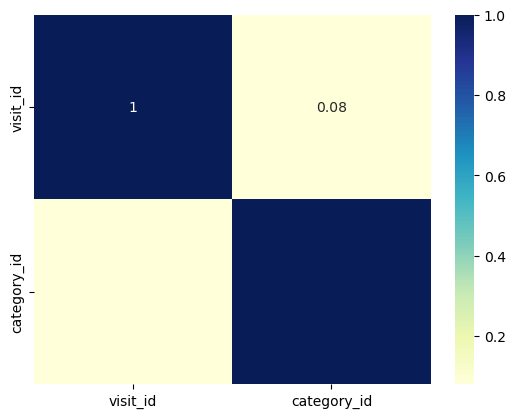

In [23]:
# plotting correlation heatmap 
dataplot = sb.heatmap(cat_df.corr(), cmap="YlGnBu", annot=True)